# Comparação das variantes do pipeline no conjunto de teste

## Objetivo

Apresenta os resultados gerais de threshold normal/fuzzy com RG/FC e compara
apenas a variante de maior Dice médio com o pipeline original (`Normal + RG`).
Todas as análises usam exclusivamente os exames comuns do conjunto de teste.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from utils.project.notebook_env import configure_notebook_environment
    REPO_ROOT = configure_notebook_environment(chdir_to_src=False)
except Exception:
    current = Path.cwd().resolve()
    REPO_ROOT = next(
        path for path in [current, *current.parents]
        if (path / "src").exists() and (path / "output").exists()
    )

SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils.visualization.variant_comparison import (
    build_dice_stats_by_variant,
    build_delta_summary_vs_reference,
    build_ranking_table,
    load_variant_results,
    plot_ostia_status_by_variant,
    plot_pair_delta_by_image,
    plot_pair_dice_by_image,
)

RESULT_ROOT = REPO_ROOT / "output/segmentation/runs/mid_res/fuzzy_comparison"
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
RESULT_ROOT

PosixPath('/home/matheus/workspace/coronary-centerline-detection/output/segmentation/runs/mid_res/fuzzy_comparison')

## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

## Carregamento dos Resultados

A análise usa o `ostios_test_summary.csv` de cada variante como fonte principal, porque esse CSV registra por imagem o método de threshold e o método arterial efetivamente usados.

In [2]:
PREFERRED_ORDER = [
    "normal_rg",
    "th_fuzzy_rg",
    "normal_fc",
    "th_fuzzy_fc",
]

PRETTY_NAMES = {
    "normal_rg": "Normal + RG",
    "th_fuzzy_rg": "Fuzzy threshold + RG",
    "normal_fc": "Normal + FC",
    "th_fuzzy_fc": "Fuzzy threshold + FC",
}

ANALYSIS_SPLIT = "test"

In [3]:
results_df, summary_df = load_variant_results(
    RESULT_ROOT,
    split=ANALYSIS_SPLIT,
    preferred_order=PREFERRED_ORDER,
    pretty_names=PRETTY_NAMES,
    repo_root=REPO_ROOT,
)

print(f"Split analisado: {ANALYSIS_SPLIT}")
print(f"Runs carregados: {summary_df.shape[0]}")
print(f"Linhas por imagem: {results_df.shape[0]}")

Split analisado: test
Runs carregados: 4
Linhas por imagem: 2800


In [4]:
display(summary_df)

,folder_variant,variant_label,run_timestamp,run_dir,n_images,threshold_mode,artery_method,ostia_detected_rate,ostia_success_rate,both_correct_n,both_tolerable_n,found_wrong_n,not_found_or_error_n,mean_dice,median_dice,std_dice,mean_dice_success_ostia,result_root
0,normal_rg,Normal + RG,2026-06-22_10-18-31,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,rg,0.994286,0.808571,60,506,130,4,0.578427,0.652087,0.196185,0.649271,/home/matheus/workspace/coronary-centerline-de...
1,th_fuzzy_rg,Fuzzy threshold + RG,2026-06-20_08-33-25,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,rg,0.990000,0.808571,51,515,127,7,0.580936,0.653493,0.195601,0.651245,/home/matheus/workspace/coronary-centerline-de...
2,normal_fc,Normal + FC,2026-06-19_09-20-42,output/segmentation/runs/mid_res/fuzzy_compari...,700,normal,fc,0.994286,0.808571,60,506,130,4,0.564721,0.636069,0.193130,0.631494,/home/matheus/workspace/coronary-centerline-de...
3,th_fuzzy_fc,Fuzzy threshold + FC,2026-06-20_23-26-14,output/segmentation/runs/mid_res/fuzzy_compari...,700,fuzzy,fc,0.990000,0.808571,51,515,127,7,0.562797,0.637484,0.193844,0.627929,/home/matheus/workspace/coronary-centerline-de...


## Detecção dos Óstios

Aqui o status é separado em: ambos corretos, ambos toleráveis, encontrados porém incorretos e não encontrado/erro.

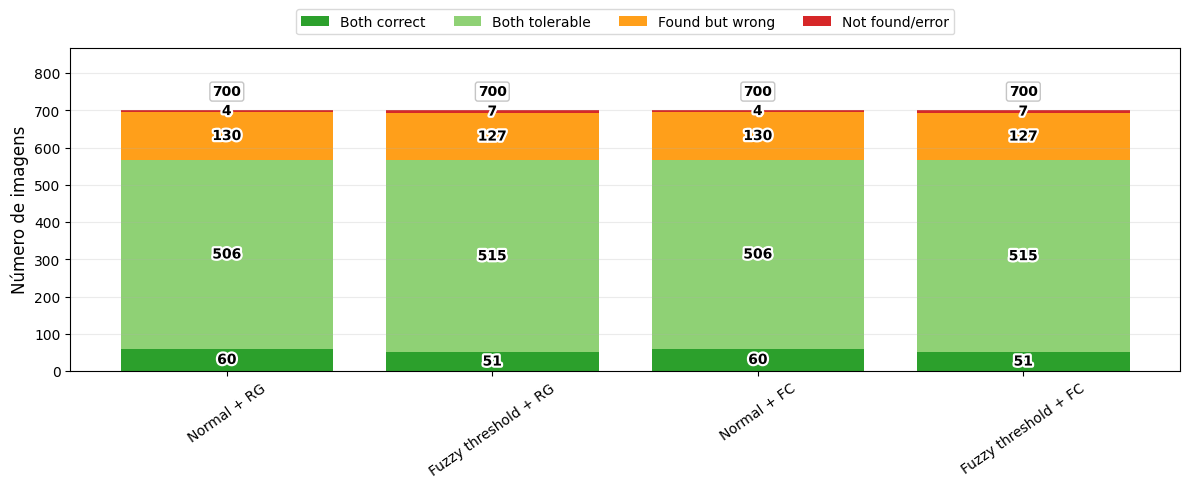

In [7]:
plot_ostia_status_by_variant(
    summary_df,
    preferred_order=PREFERRED_ORDER,
    pretty_names=PRETTY_NAMES,
    save_path=None,
)
plt.show()

## Dice Score por Variante

A tabela abaixo resume o Dice arterial por variante. O gráfico em seguida mostra média e mediana para comparação visual.

In [8]:
dice_plot = summary_df.copy()
dice_plot["variant_label"] = pd.Categorical(
    dice_plot["variant_label"],
    [PRETTY_NAMES.get(name, name) for name in PREFERRED_ORDER],
    ordered=True,
)
dice_plot = dice_plot.sort_values("variant_label")

In [9]:
dice_stats_df = build_dice_stats_by_variant(results_df, PREFERRED_ORDER)

display(dice_stats_df.round({
    "mean_dice": 4,
    "max_dice": 4,
    "min_dice": 4,
    "std_dice": 4,
    "median_dice": 4,
}))

,folder_variant,variant_label,mean_dice,max_dice,min_dice,std_dice,median_dice
0,normal_rg,Normal + RG,0.5784,0.8311,0.0,0.1962,0.6521
1,th_fuzzy_rg,Fuzzy threshold + RG,0.5809,0.8302,0.0,0.1956,0.6535
2,normal_fc,Normal + FC,0.5647,0.8155,0.0,0.1931,0.6361
3,th_fuzzy_fc,Fuzzy threshold + FC,0.5628,0.8154,0.0,0.1938,0.6375


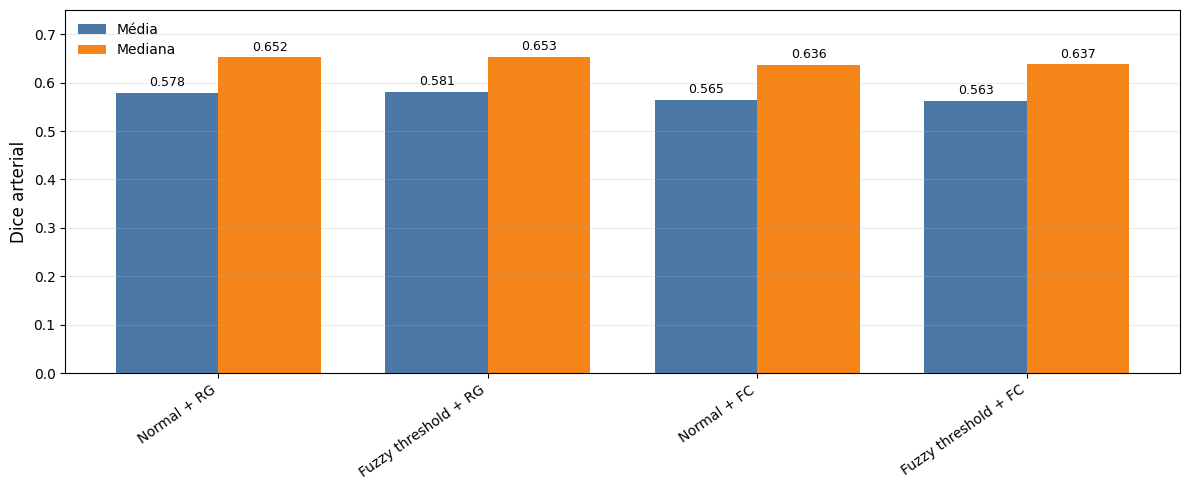

In [10]:
x = np.arange(len(dice_plot))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
mean_bars = ax.bar(x - width/2, dice_plot["mean_dice"], width, label="Média", color="#4c78a8")
median_bars = ax.bar(x + width/2, dice_plot["median_dice"], width, label="Mediana", color="#f58518")

for bars in [mean_bars, median_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.008,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(dice_plot["variant_label"].astype(str), rotation=35, ha="right")
ax.set_ylabel("Dice arterial", fontsize=12)
y_max = max(0.75, float(dice_plot[["mean_dice", "median_dice"]].max().max()) + 0.08)
ax.set_ylim(0, y_max)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Melhor variante versus baseline

A melhor variante é escolhida pelo maior Dice médio entre as alternativas. A
comparação pareada usa `Normal + RG` como baseline e somente IDs presentes nos
dois resultados. O delta é calculado como `melhor variante - baseline`.

In [11]:
baseline_variant = "normal_rg"
alternative_summary = summary_df.loc[
    summary_df["folder_variant"].astype(str) != baseline_variant
].copy()
BEST_COMPARISON_VARIANT = str(
    alternative_summary.sort_values("mean_dice", ascending=False).iloc[0]["folder_variant"]
)

best_vs_baseline_df = build_delta_summary_vs_reference(
    results_df,
    baseline_variant,
    variants=[BEST_COMPARISON_VARIANT],
    pretty_names=PRETTY_NAMES,
)

print(f"Baseline: {PRETTY_NAMES[baseline_variant]}")
print(
    "Melhor variante: "
    f"{PRETTY_NAMES.get(BEST_COMPARISON_VARIANT, BEST_COMPARISON_VARIANT)}"
)
display(best_vs_baseline_df.round({
    "mean_delta": 4,
    "median_delta": 4,
    "max_gain": 4,
    "max_loss": 4,
}))

Baseline: Normal + RG
Melhor variante: Fuzzy threshold + RG


,folder_variant,variant_label,mean_delta,median_delta,variant_better_by_0_02_n,reference_better_by_0_02_n,max_gain,max_loss
0,th_fuzzy_rg,Fuzzy threshold + RG,0.0025,0.0001,78,62,0.7976,-0.7349


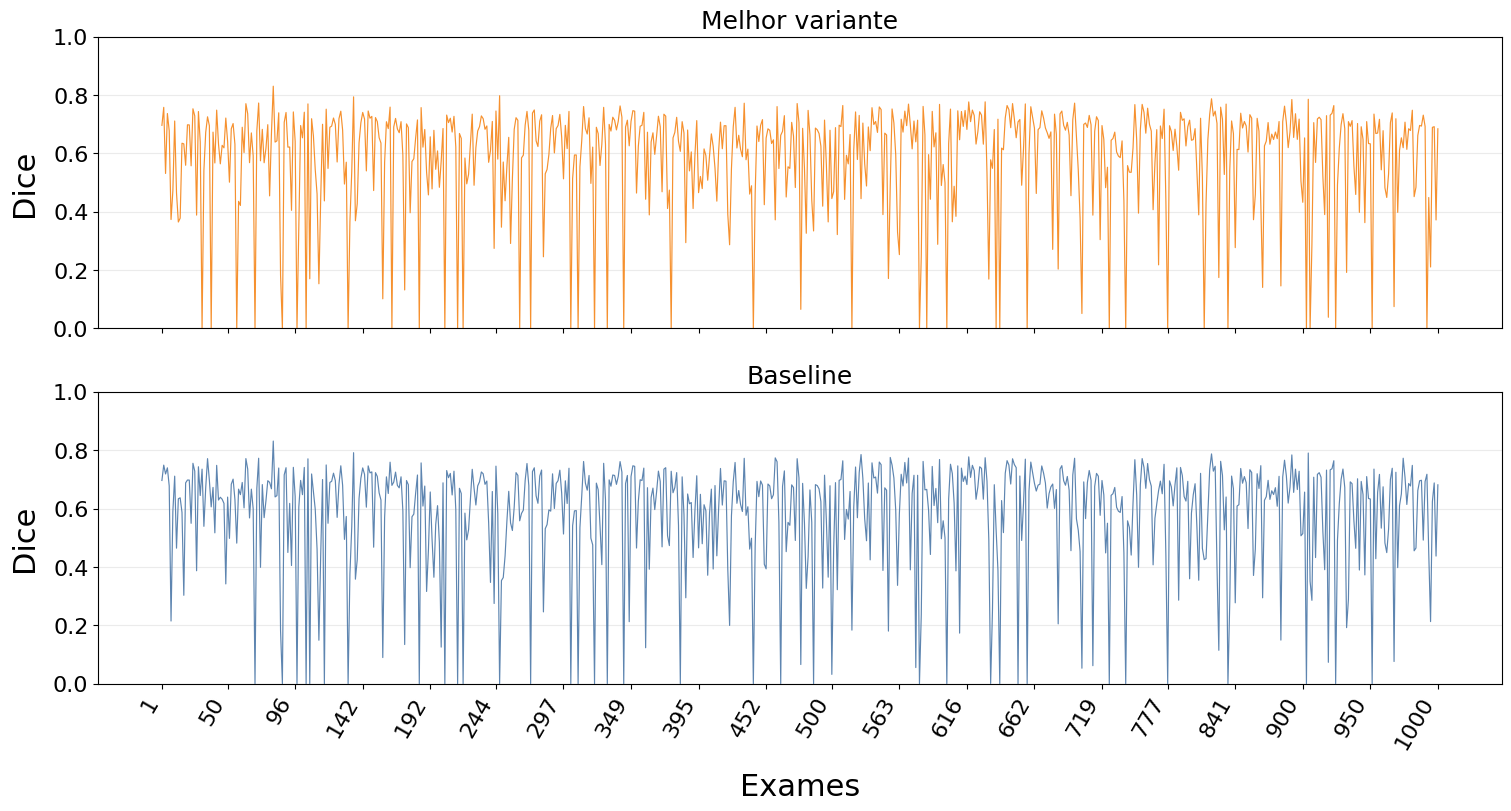

In [12]:
DICE_PANEL_NAMES = {
    baseline_variant: "Baseline",
    BEST_COMPARISON_VARIANT: "Melhor variante",
}
plot_pair_dice_by_image(
    results_df,
    baseline_variant,
    BEST_COMPARISON_VARIANT,
    pretty_names=DICE_PANEL_NAMES,
    save_path=None,
)
plt.show()

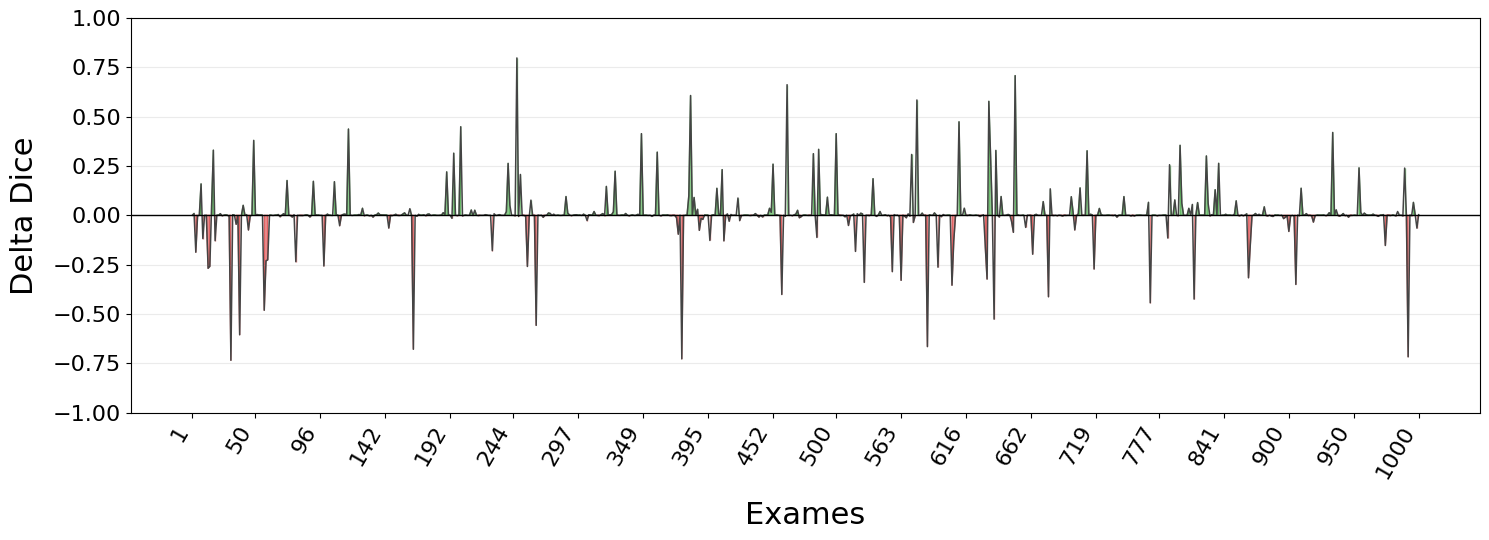

In [13]:
plot_pair_delta_by_image(
    results_df,
    baseline_variant,
    BEST_COMPARISON_VARIANT,
    pretty_names=PRETTY_NAMES,
    save_path=None,
)
plt.show()